# LaSen 충실 재현 — 리포트 (5G-26, monostatic ISAC)

*자동 생성: `lasen/build_report.py`. 그림은 base64 내장 — 커널 없이 바로 보입니다.*

**원칙:** 충실(논문 eq/param) · 단계 게이트(각 phase가 figure로 자기증명 후 다음) · viz-first. **monostatic ISAC**(gNB tx≈rx, CFR H=Y/X) — 부모 bistatic 벤치마크와 별개. 충실/비충실 정직 구분: `docs/FAITHFULNESS.md`.

## Phase A — monostatic CFR → full-band 2D-FFT RD (sanity)   ·   GATE ✅ PASS

gNB가 알려진 5G-NR X를 송신·수신 → **CFR H=Y/X**(Eq 1). Sionna로 tx≈rx 씬 + 이동 드론 → CFR. slow-time 평균빼기로 **0-Hz 클러터/self-leakage 제거**(§4.1.1) → 2D-FFT RD맵.

설정: fc=5.8 GHz · B=78.12 MHz · SCS=30 kHz · FFT=3072 · active=2604 · **N(slow)=2803 실제 OFDM 심볼(R1)** · window=100 ms · PRF=28029 Hz · dopp_res=10 Hz.

### ① monostatic 기하 + ② NR 자원격자
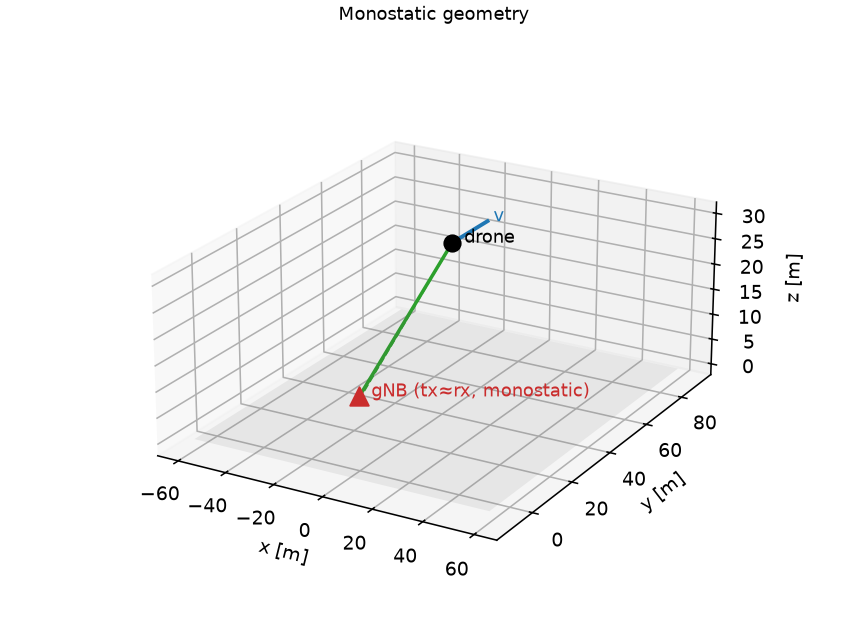
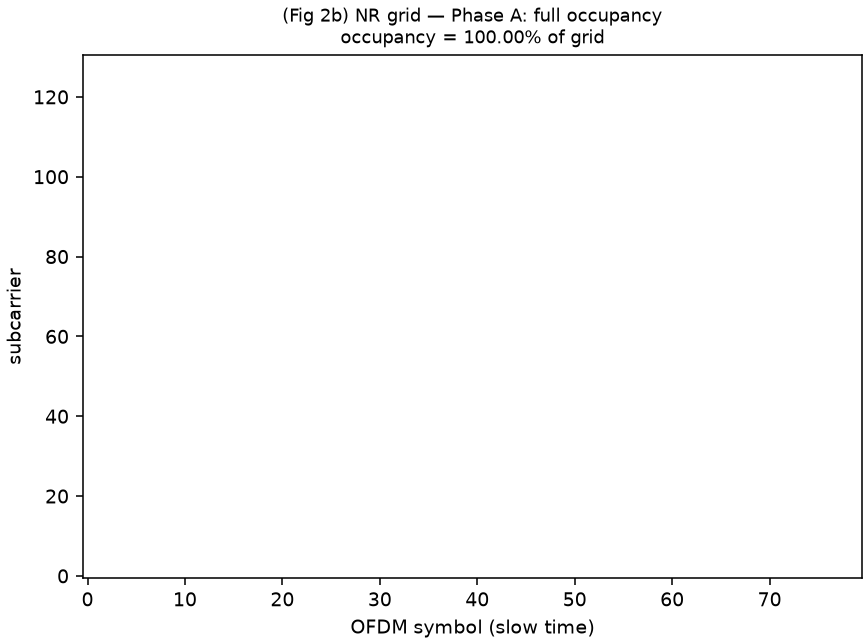
*왜:* gNB(tx≈rx)가 송·수신, 드론이 산란 → monostatic. **range=c·τ/2**(왕복지연→타깃거리), **Doppler=2v/λ**. Phase A는 **full occupancy**(모든 active RE 송신) — 비균일 점유 마스크는 Phase B.

### ③ CFR |H[t,f]| = Y/X  (Fig 3)
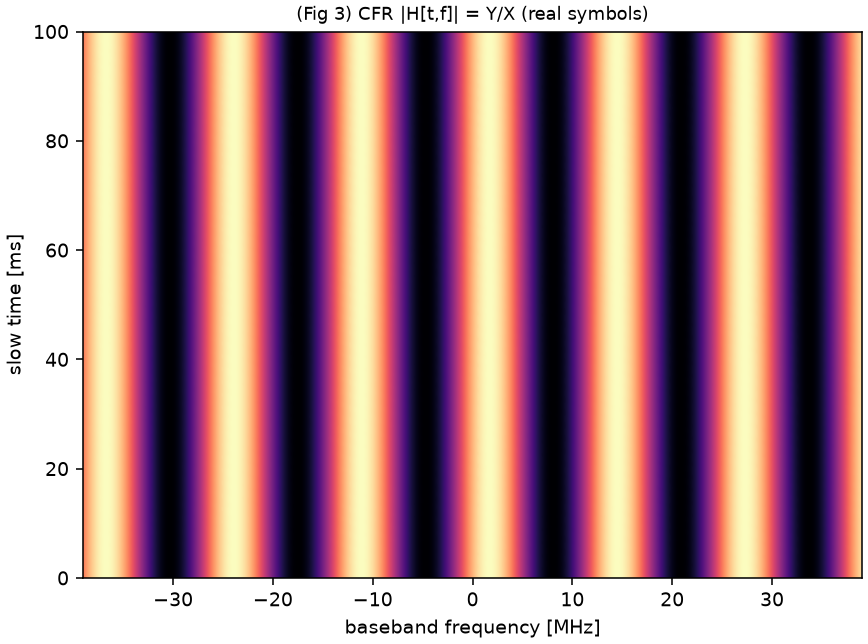
*왜:* 채널 주파수응답이 곧 H=Y/X(gNB는 X를 앎). 주파수축 줄무늬 = 지연(거리) 구조, slow-time축 = **실제 OFDM 심볼 2803개**(R1 — 점유 마스크·2D-OMP 사전이 이 위에 놓임).

### ④ RD: 정적억제 전 → 후  (Fig 4)
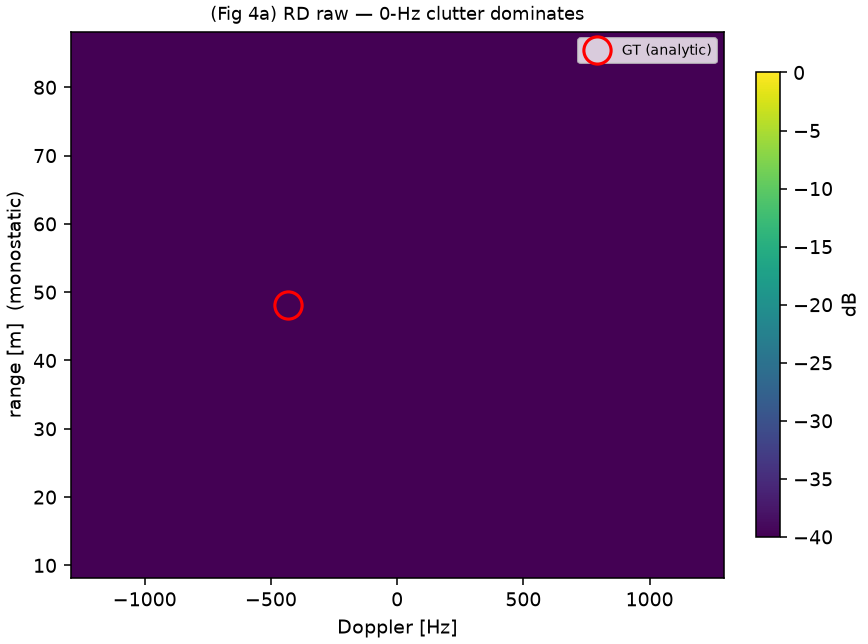
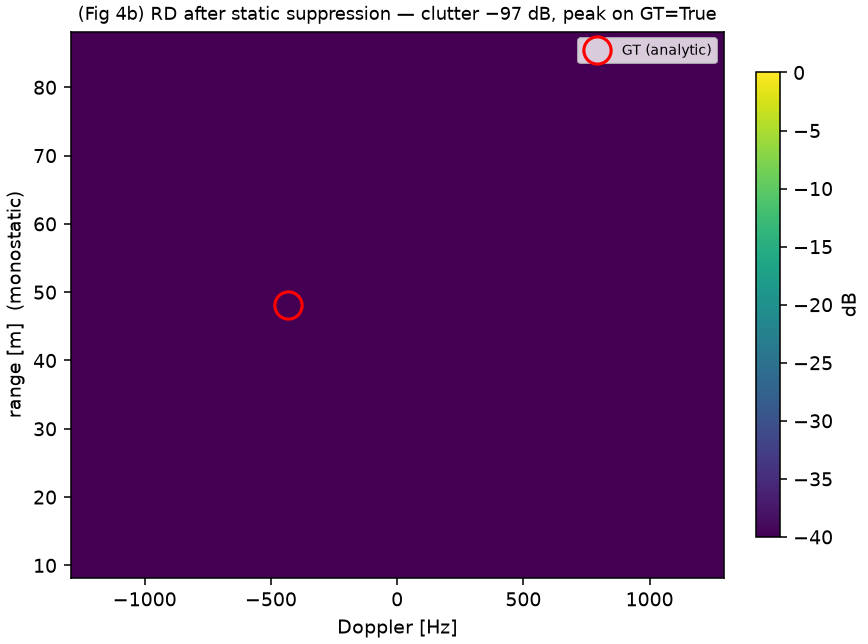
*왜:* 억제 전엔 **0-Hz 클러터/self-leakage가 지배**(드론 묻힘). slow-time 평균빼기 후 **0-Hz -97 dB 붕괴**(collapses) → 드론이 **GT 셀에 단일 피크**(range err 0.2 m, fD err 1.1 Hz, on_GT=True). LaSen Fig 4 재현.

### ⑤ Doppler↔velocity sweep  (R2 — 점 1개가 아니라 sweep)
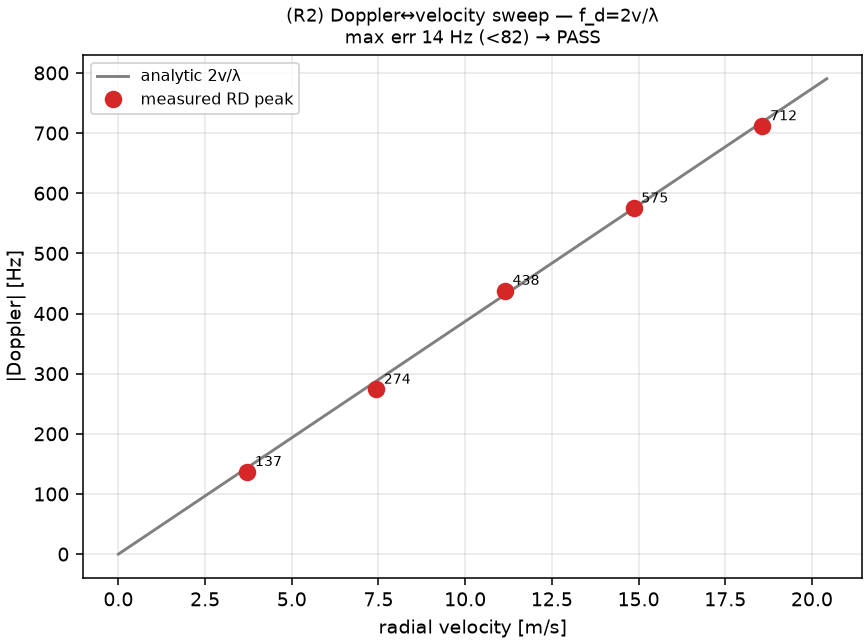
*왜:* 속도 4~20 m/s에서 측정 RD-peak Doppler가 해석적 **2v/λ** 선을 따라감 (max err **14 Hz**, pass=True). monostatic Doppler 법칙의 충실성을 1점이 아닌 추세로 증명.

→ **GATE ✅ PASS** (R1 실심볼 + R2 sweep + peak-on-GT + 클러터붕괴 모두 통과). 다음 = **Phase B**(비균일 점유 + 2D-OMP).

## Phase B — 비균일 점유 + 2D-OMP (핵심 novelty)   ·   GATE ✅ PASS

실제 5G 트래픽은 **비균일 점유**(전송된 RE만 관측) → masked CFR **ĥ = W∘H = Φz**(Eq 4-5). LaSen Fig.17/§6.4의 핵심: **강한 표적의 sub-Nyquist 마스크 누설이 약한 표적을 묻는다.** 강(near 31 m) + 약(distant 96 m, **−46 dB**) 2표적, 서로 다른 Doppler. plain 2D-FFT는 강 표적의 누설만 main-lobe 마스킹할 뿐 → sparse에서 약 표적 **놓침**; **2D-OMP**는 강 atom을 **빼내고**(Eq 6) 약 표적을 **드러냄**.

- **omp2d round-trip sub-게이트 PASS** (rd_transform(atom(di,ri))이 정확히 (di,ri) — 부호·규약 일치).
- **게이트(binary, 프록시 아님):** sparse(1.2%)에서 **2D-FFT 약표적 놓침**(예) **& 2D-OMP 잡음**(예); dense(16.0%)에선 **2D-FFT도 잡음**(예, 대조군). weak SNR: sparse FFT=7 dB(<12=놓침) vs dense FFT=20 dB.

### 점유 마스크 W + 밀도 timeline
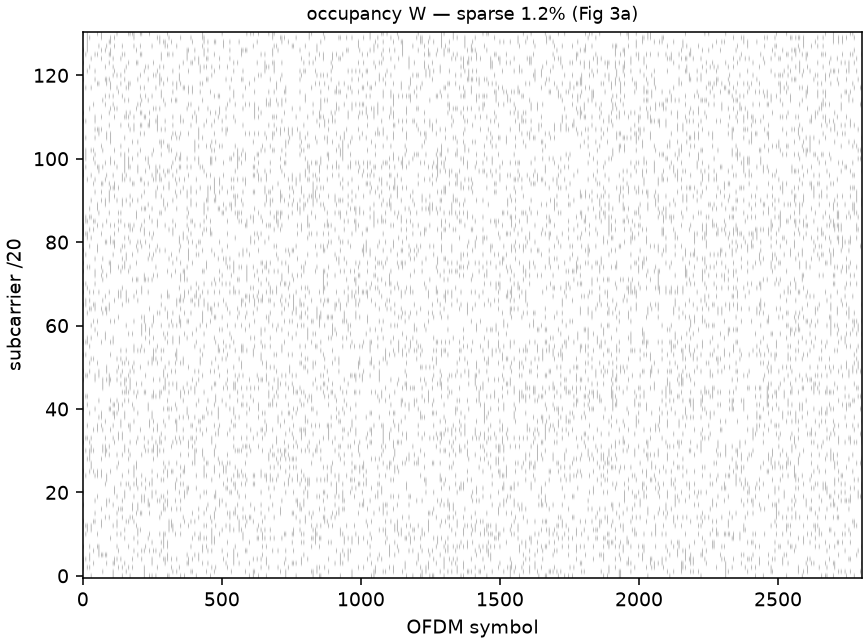
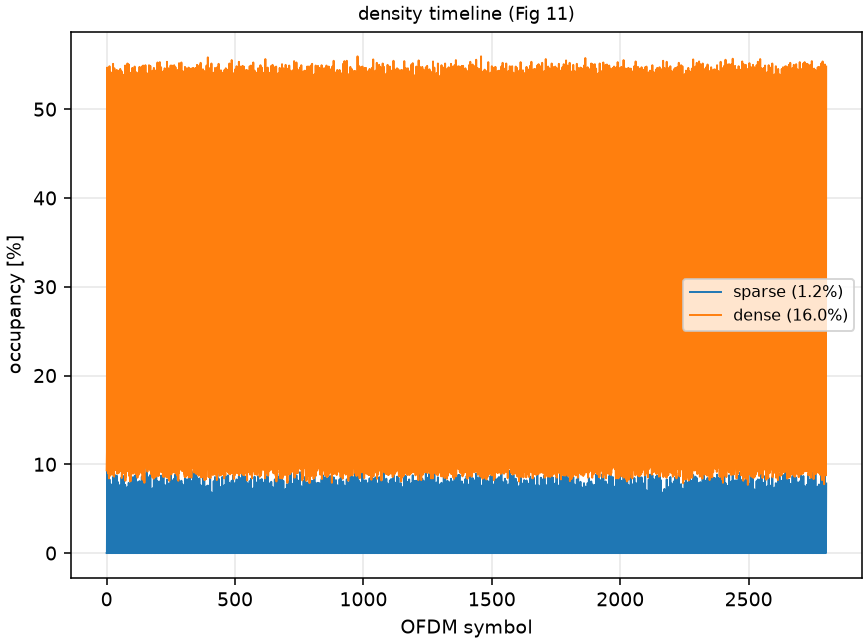
*왜:* DMRS comb 항상 + PDSCH 트래픽 — sparse일수록 관측 RE 급감(Fig 3a/11).

### RD 머니 피규어: 강의 누설이 약을 묻음(FFT) vs OMP가 둘 다 복원 (Fig 17/Tab 1)
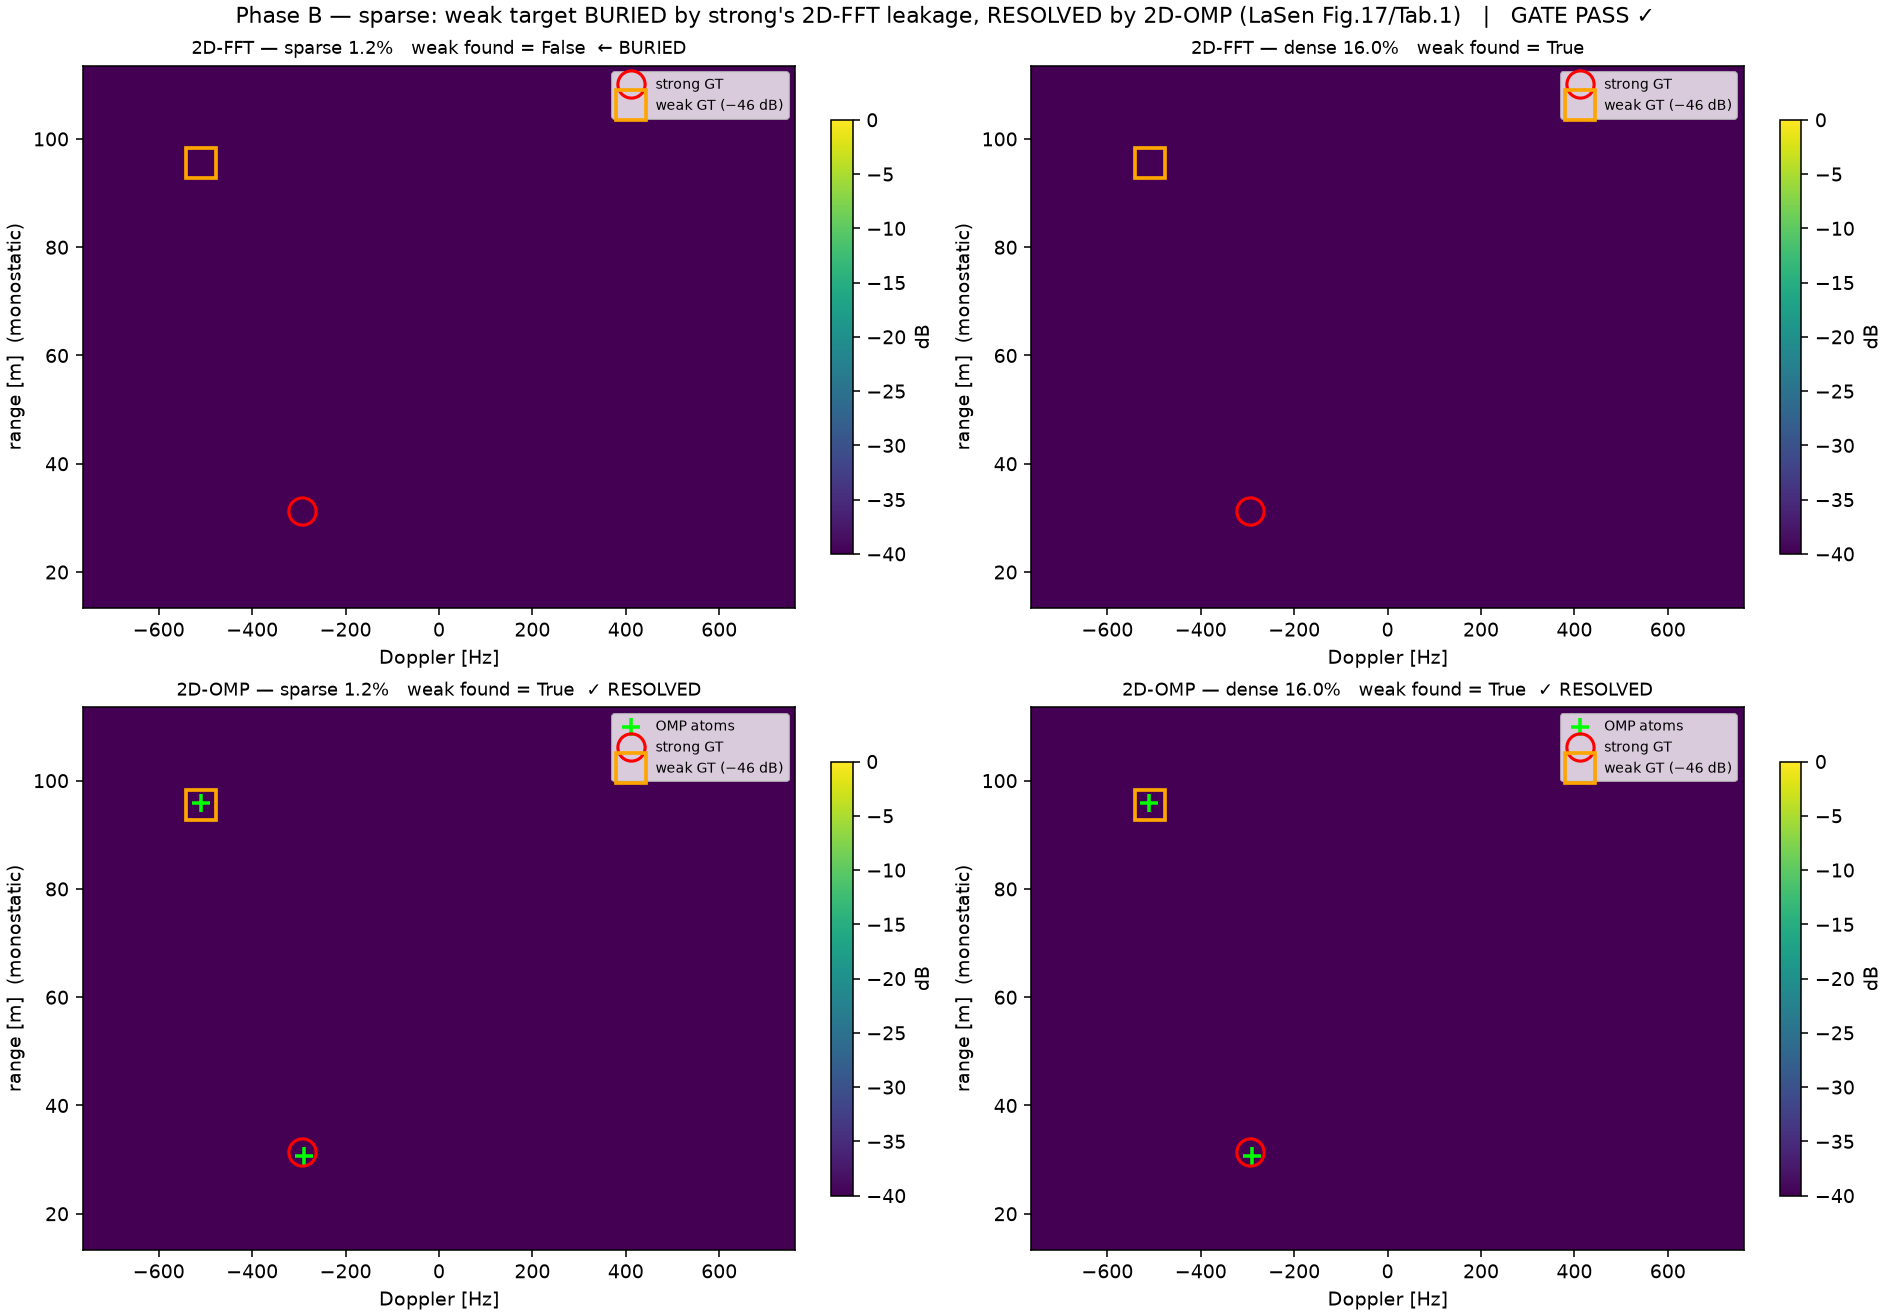
*왜:* **2D-FFT sparse(좌상)** — 약 표적(주황 □)이 강 표적 누설에 **묻혀 놓침**; **2D-OMP sparse(좌하)** — 강 atom 제거 후 약 표적까지 **복원**(초록 + = 복원 atom). dense(우)에선 누설↓라 FFT도 잡음.

### 2D-OMP 수렴 (강→약 순서로 atom 선택)
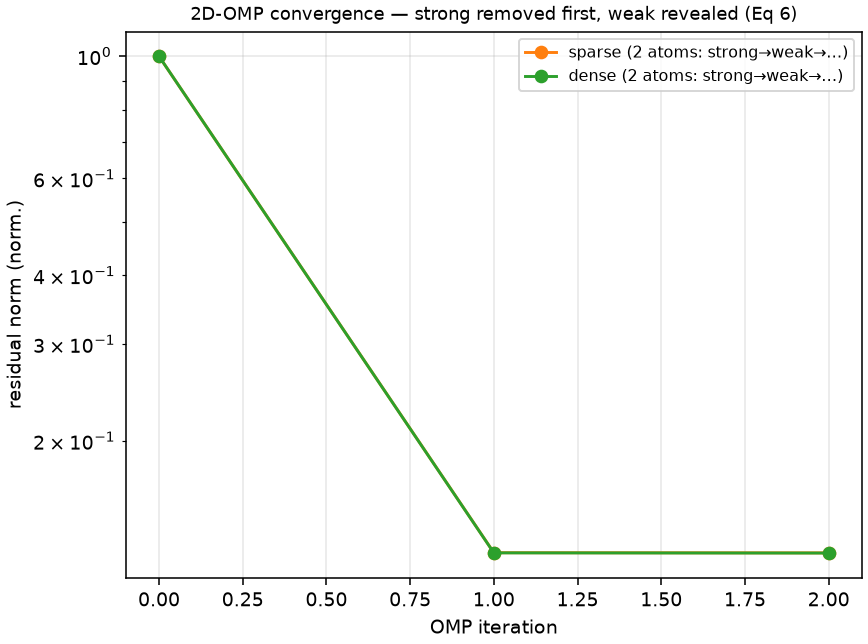
*왜:* OMP가 강 표적을 먼저 빼고 잔차에서 약 표적을 드러냄(atoms: sparse 2 / dense 2).

### R1 수렴체크 — n_slow 불변성 (필수)
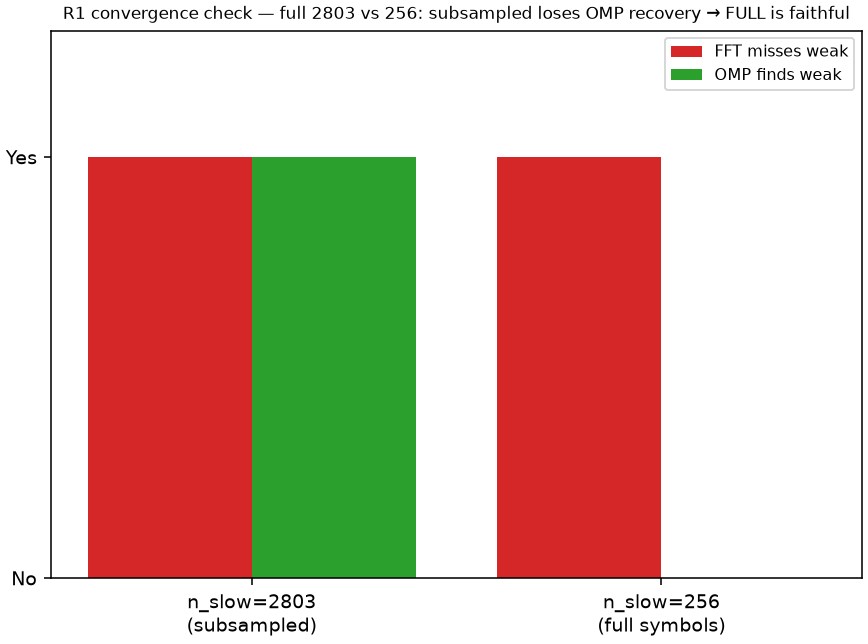
*왜:* 게이트 verdict를 n_slow ∈ {2803, 256}에서 비교. **불변 아님**: full 2803에선 OMP가 약 표적 복원하나 subsample 256에선 못 함 → **256은 비충실, full 2803(실제 OFDM 심볼)로 실행**(R1 절 준수, 게이트는 full에서 PASS).

→ **GATE ✅ PASS** (full 2803 실심볼). 다음 = Phase C(ID score + global/local + Kalman 추적).

_정직 노트: 2표적은 **clean point-target atoms**(점표적 CFR=atom; RT 충실성은 Phase A가 확립, 드론 다중경로 spread가 약-표적 복원을 가리는 것 회피). 약 echo는 **deterministic −gap dB**(부모 fix #4). 상세: `docs/FAITHFULNESS.md`._